In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Configuración visual para gráficos estilo "Dark Mode" de telemetría
plt.style.use('dark_background')
sns.set_palette("husl")

BASE_DIR = 'C:/Users/marce/F1-data-project/project/'
print("🚀 Librerías cargadas. Listos para el PCA.")

🚀 Librerías cargadas. Listos para el PCA.


In [5]:
# ==========================================
# 2. CARGA, INGENIERÍA Y PREPARACIÓN DE DATOS
# ==========================================
# Carga del archivo final
file_path = f"{BASE_DIR}/data/processed/tactical_events_v2_FINAL.parquet"
df_polars = pl.read_parquet(file_path)
df = df_polars.to_pandas()

# --- LA MAGIA DEL NEUMÁTICO (Ordinal Encoding) ---
grip_map = {
    'SOFT': 3,
    'MEDIUM': 2,
    'HARD': 1,
    'INTERMEDIATE': 0,
    'WET': -1
}

# Si hay nulos en los compuestos (ej. la API no los trajo), los rellenamos con un string temporal
df['att_compound'] = df['att_compound'].fillna('UNKNOWN')
df['def_compound'] = df['def_compound'].fillna('UNKNOWN')

# Mapeamos a números
df['att_grip'] = df['att_compound'].map(grip_map)
df['def_grip'] = df['def_compound'].map(grip_map)

# El Delta Mágico: +2 significa que el atacante tiene ventaja masiva de agarre
df['delta_grip'] = df['att_grip'] - df['def_grip']

# --- SEPARACIÓN DE VARIABLES ---
# Metadatos (No entran al cálculo matemático del PCA)
metadata_cols = [
    'event_id', 'race_name', 'lap_number', 'event_type', 
    'attacker', 'defender', 'att_compound', 'def_compound', 'pos_change',
    'att_grip', 'def_grip' # Dejamos los agarres individuales fuera del PCA para no meter ruido
]

# Todo lo que no sea metadato, es un feature numérico para el modelo (incluyendo el delta_grip)
feature_cols = [col for col in df.columns if col not in metadata_cols]

X_raw = df[feature_cols].copy()
y_metadata = df[metadata_cols].copy()

print(f"📊 Total de eventos listos: {len(df)}")
print(f"🧬 Variables numéricas inyectadas al PCA: {len(feature_cols)} ")

📊 Total de eventos listos: 234
🧬 Variables numéricas inyectadas al PCA: 197 


In [7]:
# ==========================================
# 3. LIMPIEZA Y ESCALADO (EL MOTOR DE MACHINE LEARNING)
# ==========================================
# 0. Limpieza previa: Eliminar "Columnas Fantasma"
# Si un sensor tiene 100% de datos nulos en los 234 eventos, lo descartamos
X_raw_clean = X_raw.dropna(axis=1, how='all')

# Guardamos la nueva lista de columnas que "sobrevivieron" a la purga
feature_cols_clean = X_raw_clean.columns.tolist()

columnas_eliminadas = len(feature_cols) - len(feature_cols_clean)
print(f"🧹 Columnas eliminadas por falta total de datos (100% Nulas): {columnas_eliminadas}")

# 1. Rellenar Nulos (Imputación por la Mediana)
# Ahora sí, rellenamos los nulos parciales con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw_clean)

# 2. Estandarización (Crucial para el PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Lo devolvemos a formato DataFrame usando la lista de nombres LIMPIA
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols_clean)

print(f"✅ Datos limpios y estandarizados. ¡Variables finales listas para el PCA: {df_scaled.shape[1]}!")

🧹 Columnas eliminadas por falta total de datos (100% Nulas): 15
✅ Datos limpios y estandarizados. ¡Variables finales listas para el PCA: 182!


In [10]:
df.isna().sum()

event_id                      0
race_name                     0
lap_number                    0
event_type                    0
attacker                      0
                           ... 
delta_drs_max_lap_std       234
delta_drs_max_lap_median    234
att_grip                    127
def_grip                    122
delta_grip                  163
Length: 208, dtype: int64

In [8]:
feature_cols_clean

['delta_tyre_age',
 'att_lap_duration_mean',
 'att_lap_duration_max',
 'att_lap_duration_min',
 'att_lap_duration_std',
 'att_lap_duration_median',
 'def_lap_duration_mean',
 'def_lap_duration_max',
 'def_lap_duration_min',
 'def_lap_duration_std',
 'def_lap_duration_median',
 'delta_lap_duration_mean',
 'delta_lap_duration_max',
 'delta_lap_duration_min',
 'delta_lap_duration_std',
 'delta_lap_duration_median',
 'att_duration_sector_1_mean',
 'att_duration_sector_1_max',
 'att_duration_sector_1_min',
 'att_duration_sector_1_std',
 'att_duration_sector_1_median',
 'def_duration_sector_1_mean',
 'def_duration_sector_1_max',
 'def_duration_sector_1_min',
 'def_duration_sector_1_std',
 'def_duration_sector_1_median',
 'delta_duration_sector_1_mean',
 'delta_duration_sector_1_max',
 'delta_duration_sector_1_min',
 'delta_duration_sector_1_std',
 'delta_duration_sector_1_median',
 'att_duration_sector_2_mean',
 'att_duration_sector_2_max',
 'att_duration_sector_2_min',
 'att_duration_sector

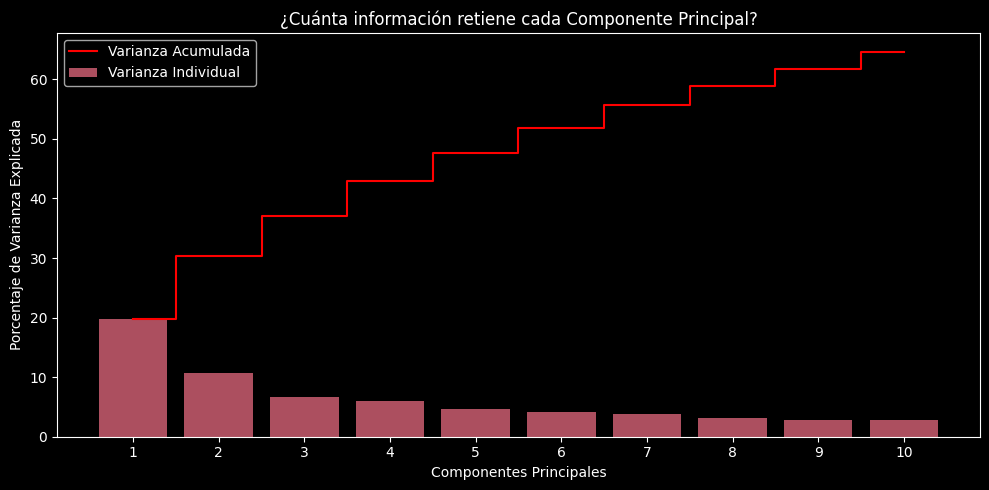

💡 El Componente 1 (PC1) retiene el 19.78% de la información original.
💡 El PC1 y PC2 juntos retienen el 30.41% de la información.


In [11]:
# ==========================================
# 4. ENTRENAMIENTO DEL PCA
# ==========================================
# Inicializamos el PCA (vamos a pedirle 10 componentes para analizar)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(df_scaled)

# Calcular la varianza explicada
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

# Gráfico del "Codo" (Scree Plot)
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), explained_variance, alpha=0.7, align='center', label='Varianza Individual')
plt.step(range(1, 11), cumulative_variance, where='mid', color='red', label='Varianza Acumulada')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('¿Cuánta información retiene cada Componente Principal?')
plt.xticks(range(1, 11))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"💡 El Componente 1 (PC1) retiene el {explained_variance[0]:.2f}% de la información original.")
print(f"💡 El PC1 y PC2 juntos retienen el {cumulative_variance[1]:.2f}% de la información.")

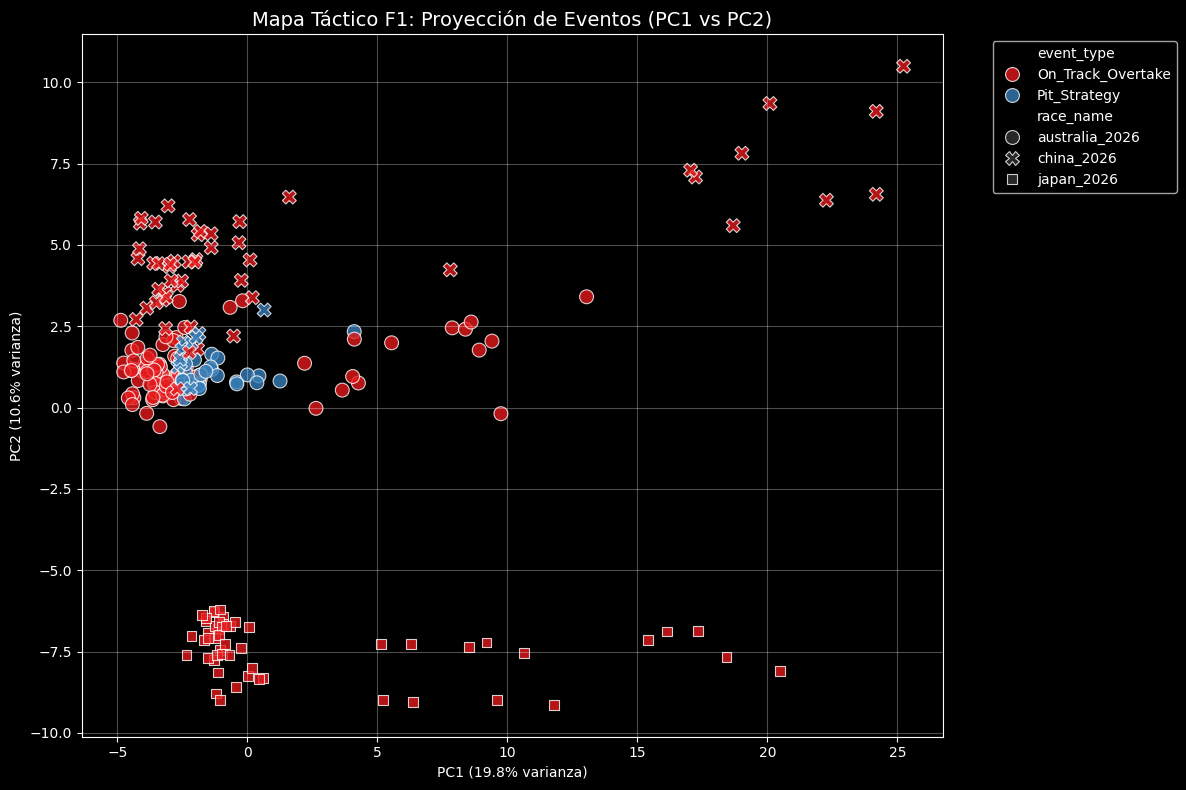

In [12]:
# ==========================================
# 5. VISUALIZACIÓN DE CLÚSTERES TÁCTICOS
# ==========================================
# Creamos un DataFrame con los resultados del PCA y le pegamos las etiquetas
df_pca_viz = pd.DataFrame(data = X_pca[:, :2], columns = ['PC1', 'PC2'])
df_pca_viz = pd.concat([df_pca_viz, y_metadata[['event_type', 'race_name']]], axis=1)

# Gráfico de Dispersión
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='event_type', 
    style='race_name',
    palette='Set1', 
    data=df_pca_viz, 
    s=100, alpha=0.8, edgecolor='w'
)

plt.title('Mapa Táctico F1: Proyección de Eventos (PC1 vs PC2)', fontsize=14)
plt.xlabel(f'PC1 ({explained_variance[0]:.1f}% varianza)')
plt.ylabel(f'PC2 ({explained_variance[1]:.1f}% varianza)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

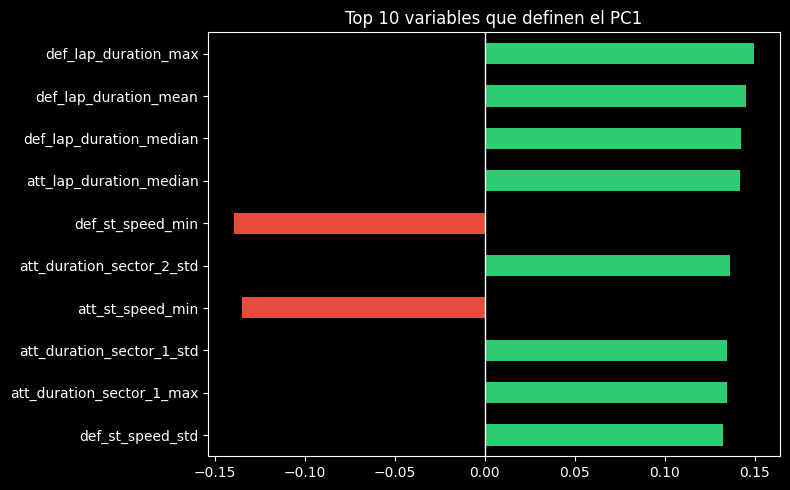

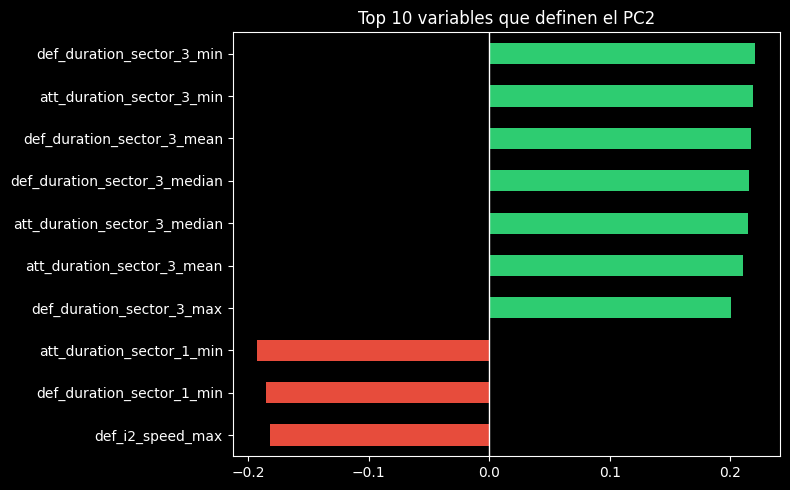

In [14]:
# ==========================================
# 6. ANÁLISIS DE PESOS (LOADINGS)
# ==========================================
# Extraemos los pesos de los componentes usando la lista LIMPIA (182 variables)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i}' for i in range(1, 11)], 
    index=feature_cols_clean  # <--- EL CAMBIO MÁGICO ESTÁ AQUÍ
)

def plot_top_loadings(pc_name, top_n=10):
    # Ordenar por valor absoluto para ver el impacto real (positivo o negativo)
    top_vars = loadings[pc_name].abs().sort_values(ascending=False).head(top_n)
    real_values = loadings.loc[top_vars.index, pc_name]
    
    plt.figure(figsize=(8, 5))
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in real_values]
    real_values.plot(kind='barh', color=colors)
    plt.title(f'Top {top_n} variables que definen el {pc_name}')
    plt.axvline(0, color='white', linewidth=1)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Ver qué variables dominan los dos ejes principales
plot_top_loadings('PC1')
plot_top_loadings('PC2')
